In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data = pd.read_csv('knn_regression_dataset.csv')
data.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1000 non-null   int64  
 1   income           970 non-null    float64
 2   loan_amount      970 non-null    float64
 3   credit_score     971 non-null    float64
 4   city             1000 non-null   object 
 5   employment_type  1000 non-null   object 
 6   target           1000 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB


In [3]:
data.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [4]:
data.describe()

,age,income,loan_amount,credit_score,target
count,1000.00000,970.000000,970.000000,971.000000,1000.000000
mean,43.81900,52924.860515,204508.531872,649.422223,125258.332699
std,14.99103,21236.060048,58239.083910,71.104784,31423.294558
min,18.00000,6556.169327,49024.392209,440.620482,40800.918241
25%,31.00000,40854.271568,168890.053957,600.334270,105707.679044
50%,44.00000,51119.925190,200190.693629,649.978043,123651.542971
75%,56.00000,61104.364633,235458.241233,696.092859,141801.468844
max,69.00000,220985.397589,597644.058452,858.968130,333440.450713


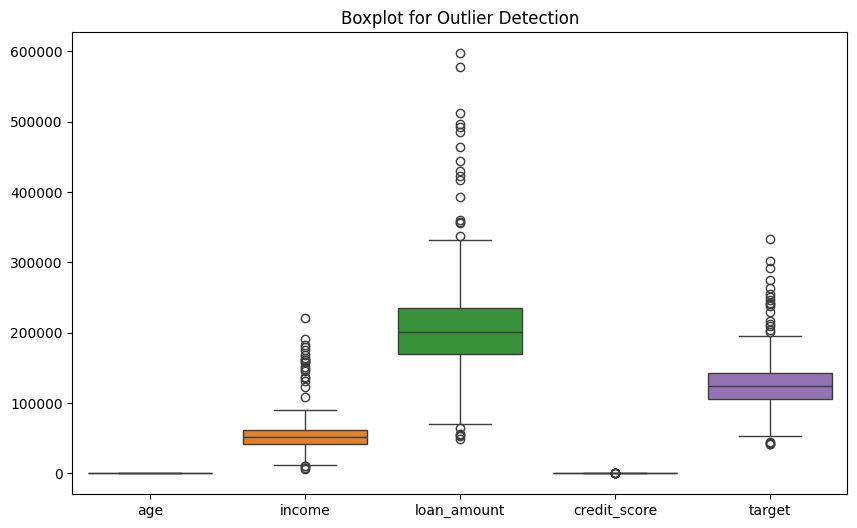

In [5]:
#outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)
plt.title('Boxplot for Outlier Detection')
plt.show()


In [18]:
data['income']=data['income'].fillna(data['income'].median())
data['loan_amount']=data['loan_amount'].fillna(data['loan_amount'].median())
data['credit_score']=data['credit_score'].fillna(data['credit_score'].median())

In [20]:
data.isna().sum()

age                0
income             0
loan_amount        0
credit_score       0
city               0
employment_type    0
target             0
dtype: int64

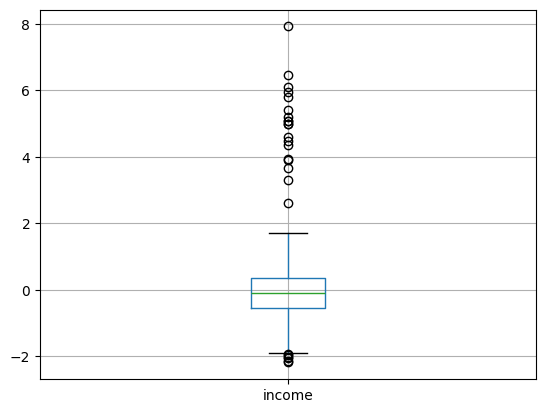

In [21]:
import matplotlib.pyplot as plt 
import seaborn as sns
data[['income']].boxplot()
plt.show()


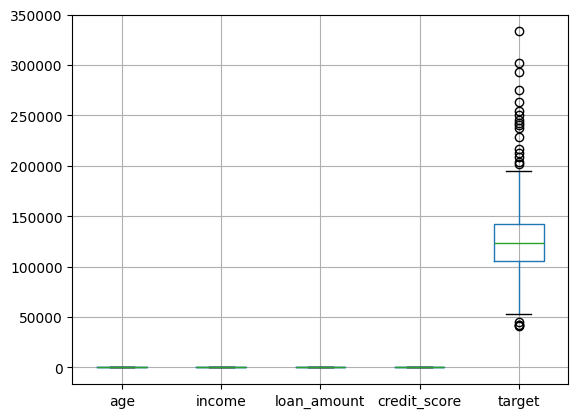

In [24]:
 #use the clip method to cap the outliers in income column
def cap_outliers(column):
    Q1=data[column].quantile(0.25)
    Q3=data[column].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    return data[column].clip(lower_bound, upper_bound)

data['income']=cap_outliers('income')
data['loan_amount']=cap_outliers('loan_amount')
data['credit_score']=cap_outliers('credit_score')
data.boxplot()
plt.show()

In [25]:
 Q1=data['income'].quantile(0.25)
 Q3=data['income'].quantile(0.75)
 IQR=Q3-Q1
 lower_bound=Q1-1.5*IQR
 upper_bound=Q3+1.5*IQR
 data=data[(data['income']>=lower_bound) & (data['income']<=upper_bound)]


In [8]:
#handled the scale data
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
normal_skew=['income','loan_amount']
scale=MinMaxScaler()
data[normal_skew]=scaler.fit_transform(data[normal_skew])


In [9]:
data.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,-1.273094,1.405961,789.476075,Chennai,Salaried,158793.631698
1,69,0.005988,-0.420731,596.334039,Chennai,Salaried,115596.093965
2,46,-0.672323,0.115544,611.531000,Chennai,Salaried,127231.057638
3,32,-1.142923,0.723616,710.171152,Chennai,Unemployed,145102.187078
4,60,-0.594741,-1.295792,622.900855,Hyderabad,Unemployed,110623.128404


In [13]:
data['credit_score']=scaler.fit_transform(data[['credit_score']])

In [15]:
data.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,-1.273094,1.405961,1.970698,Chennai,Salaried,158793.631698
1,69,0.005988,-0.420731,-0.747004,Chennai,Salaried,115596.093965
2,46,-0.672323,0.115544,-0.533167,Chennai,Salaried,127231.057638
3,32,-1.142923,0.723616,0.854798,Chennai,Unemployed,145102.187078
4,60,-0.594741,-1.295792,-0.373182,Hyderabad,Unemployed,110623.128404


In [26]:
# Encode the 'city' column using one-hot encoding
data= pd.get_dummies(data, columns=['city'])
data.head()


,age,income,loan_amount,credit_score,employment_type,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai
0,56,-1.273094,1.405961,1.970698,Salaried,158793.631698,False,True,False,False
1,69,0.005988,-0.420731,-0.747004,Salaried,115596.093965,False,True,False,False
2,46,-0.672323,0.115544,-0.533167,Salaried,127231.057638,False,True,False,False
3,32,-1.142923,0.723616,0.854798,Unemployed,145102.187078,False,True,False,False
4,60,-0.594741,-1.295792,-0.373182,Unemployed,110623.128404,False,False,True,False


In [27]:
data = pd.get_dummies(data, columns=['employment_type'])
data.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,-1.273094,1.405961,1.970698,158793.631698,False,True,False,False,True,False,False
1,69,0.005988,-0.420731,-0.747004,115596.093965,False,True,False,False,True,False,False
2,46,-0.672323,0.115544,-0.533167,127231.057638,False,True,False,False,True,False,False
3,32,-1.142923,0.723616,0.854798,145102.187078,False,True,False,False,False,False,True
4,60,-0.594741,-1.295792,-0.373182,110623.128404,False,False,True,False,False,False,True


In [28]:
# Ignore ther warnings
import warnings
warnings.filterwarnings('ignore')

In [32]:
data['city_Bangalore'].replace({True: 1, False: 0}, inplace=True)
data['city_Chennai'].replace({True: 1, False: 0}, inplace=True)
data['city_Hyderabad'].replace({True: 1, False: 0}, inplace=True)
data['city_Mumbai'].replace({True: 1, False: 0}, inplace=True)
data['employment_type_Salaried'].replace({True: 1, False: 0}, inplace=True)
data['employment_type_Self-Employed'].replace({True: 1, False: 0}, inplace=True)
data['employment_type_Unemployed'].replace({True: 1, False: 0}, inplace=True)
data.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,-1.273094,1.405961,1.970698,158793.631698,0,1,0,0,1,0,0
1,69,0.005988,-0.420731,-0.747004,115596.093965,0,1,0,0,1,0,0
2,46,-0.672323,0.115544,-0.533167,127231.057638,0,1,0,0,1,0,0
3,32,-1.142923,0.723616,0.854798,145102.187078,0,1,0,0,0,0,1
4,60,-0.594741,-1.295792,-0.373182,110623.128404,0,0,1,0,0,0,1


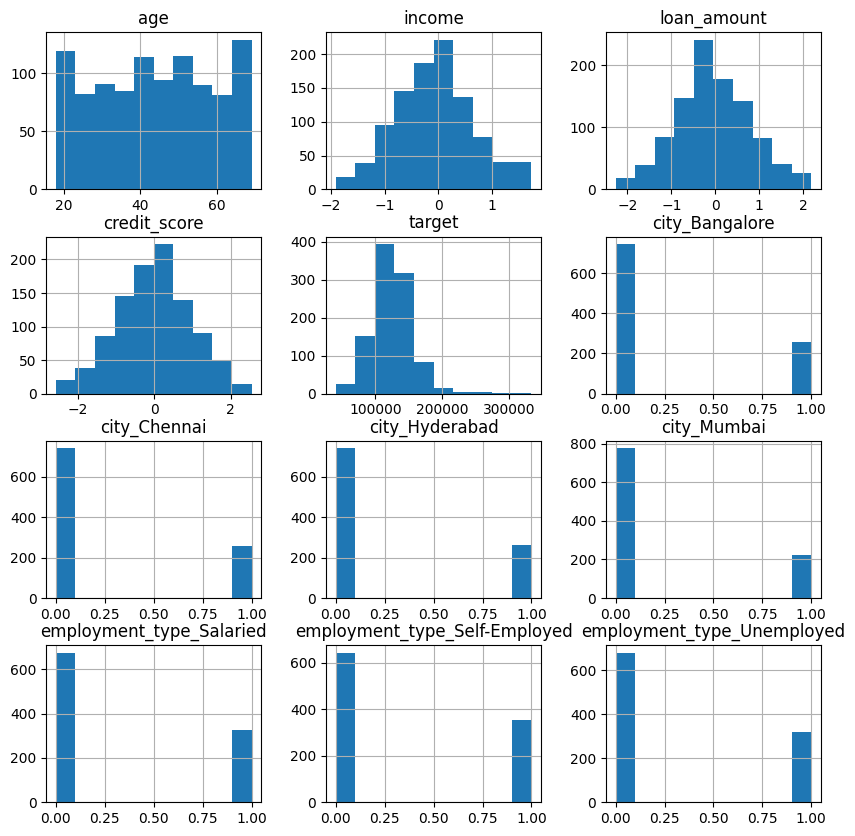

In [33]:
data.hist(figsize=(10,10))
plt.show()

In [35]:
# check the normal , postive skewness and negative skewness features
data.skew()


age                             -0.042322
income                           0.187505
loan_amount                      0.134521
credit_score                    -0.044087
target                           1.139328
city_Bangalore                   1.119865
city_Chennai                     1.101895
city_Hyderabad                   1.095950
city_Mumbai                      1.319085
employment_type_Salaried         0.748388
employment_type_Self-Employed    0.602389
employment_type_Unemployed       0.777843
dtype: float64

In [39]:
# Train-test split
from sklearn.model_selection import train_test_split

X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Just to view first few rows (optional)
print(X_train.head())
print(y_train.head())

# Train KNN model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

     age    income  loan_amount  credit_score  city_Bangalore  city_Chennai  \
29    42 -0.173306    -0.243802      0.547169               0             0   
535   22 -0.479769    -1.798718     -2.579318               0             0   
695   65 -0.207300     0.081233     -0.485736               1             0   
557   29  0.602193    -1.597042     -0.195376               1             0   
836   54 -0.568550    -0.557020      1.113126               0             1   

     city_Hyderabad  city_Mumbai  employment_type_Salaried  \
29                1            0                         0   
535               0            1                         0   
695               0            0                         0   
557               0            0                         1   
836               0            0                         0   

     employment_type_Self-Employed  employment_type_Unemployed  
29                               1                           0  
535                   

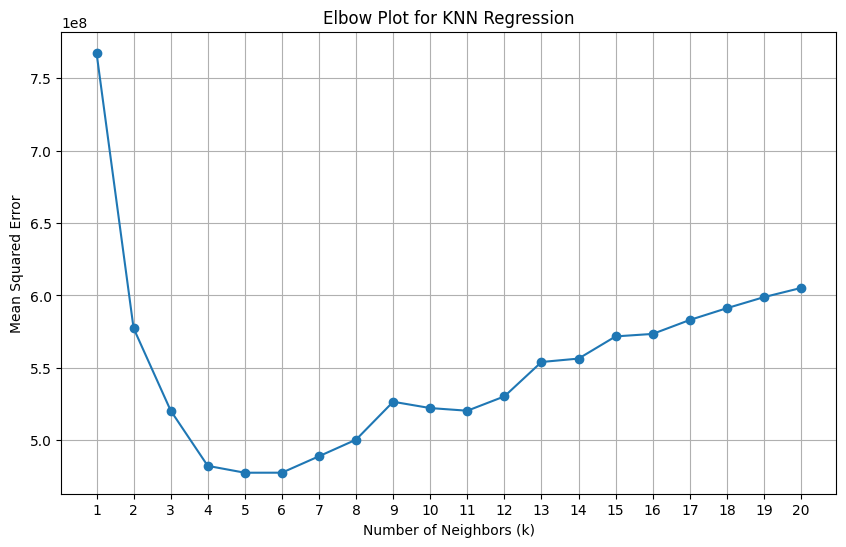

In [40]:
#plot the elbow plot to find the optimal number of neighbors\

from sklearn.neighbors import KNeighborsRegressor
mse_values = []
for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), mse_values, marker='o')
plt.title('Elbow Plot for KNN Regression')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Squared Error')
plt.xticks(range(1, 21))
plt.grid()
plt.show()


In [41]:
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

In [42]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

In [43]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 477589618.802599
R2: 0.5422325222583442


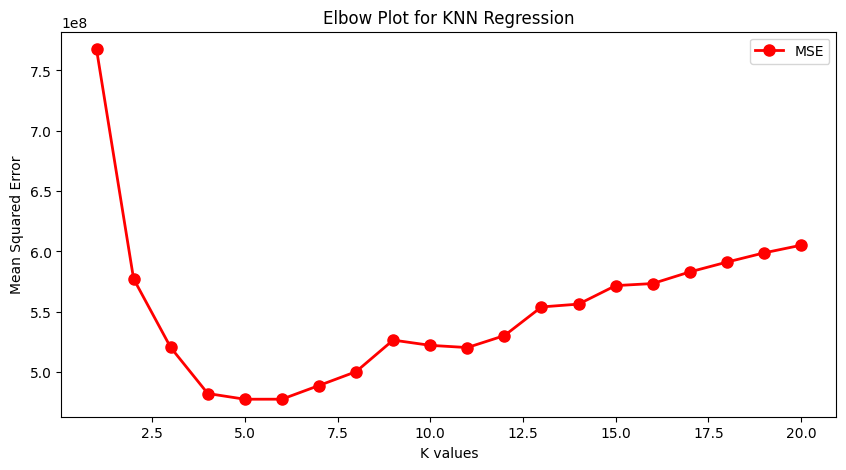

In [44]:
# make the elbow plot to find the optimal value of k
mse_values = []
k_values = range(1, 21)
 
for k in k_values:
    # load the model
    knn_regressor = KNeighborsRegressor(n_neighbors=k)
 
    # fit the model on the training data
    knn_regressor.fit(X_train, y_train)
 
    #predict the target variable on the testing data
    y_pred = knn_regressor.predict(X_test)
 
    #find the MSE
    mse = mean_squared_error(y_test, y_pred)
 
    #append the MSE value to the list
    mse_values.append(mse)
 
# plot the elbow plot
plt.figure(figsize=(10,5))
plt.plot(k_values, mse_values, marker='o',color='red',linewidth=2,markersize=8,label='MSE',)
plt.title("Elbow Plot for KNN Regression")
plt.xlabel("K values")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()
 

In [48]:

#linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression Mean Squared Error: ", mse_lr)
print("Linear Regression R-squared: ", r2_lr)

Linear Regression Mean Squared Error:  204308498.008082
Linear Regression R-squared:  0.8041712337700485


In [49]:
#decsion tree regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print("Decision Tree Mean Squared Error: ", mse_dt)
print("Decision Tree R-squared: ", r2_dt)

Decision Tree Mean Squared Error:  541257909.1280563
Decision Tree R-squared:  0.4812067555185219


In [50]:
#linear regression, decision tree regressor and knn regression comparison
print("Linear Regression Mean Squared Error: ", mse_lr)
print("Linear Regression R-squared: ", r2_lr)
print("KNN Regression Mean Squared Error: ", mse)
print("KNN Regression R-squared: ", r2)
print("Decision Tree Mean Squared Error: ", mse_dt)

print("Decision Tree R-squared: ", r2_dt)


Linear Regression Mean Squared Error:  204308498.008082
Linear Regression R-squared:  0.8041712337700485
KNN Regression Mean Squared Error:  605170879.4315941
KNN Regression R-squared:  0.5422325222583442
Decision Tree Mean Squared Error:  541257909.1280563
Decision Tree R-squared:  0.4812067555185219
